<a href="https://colab.research.google.com/github/Bhanvi08/Facial-Recognition-PCA-ANN/blob/main/iStudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Author: BHANVI SINGH CHAUHAN | bhanvisinghchauhan08@gmail.com | 9165905495
# 1. Command Colab to download and extract the dataset automatically
!wget -qO dataset.zip https://github.com/robaita/introduction_to_machine_learning/raw/main/dataset.zip
!unzip -qo dataset.zip -d face_data

import os
import cv2
import numpy as np
from scipy.sparse.linalg import eigsh

print("Processing face images...")

# 2. Find every image, RESIZE IT, and flatten it into a column vector
image_vectors = []
target_size = (100, 100) # Force every image to be 100x100 pixels (10,000 total pixels)

for root, dirs, files in os.walk('face_data'):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.pgm')):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                # The magic line that fixes the inhomogeneous error:
                img_resized = cv2.resize(img, target_size)
                image_vectors.append(img_resized.flatten())

# 3. Create the Database so it perfectly matches the (mn x p) format
face_db = np.array(image_vectors).T
mn, p = face_db.shape
print(f"Face Database Shape: {mn} pixels (mn) x {p} images (p)")

# 4. Do Mean Zero and calculate the Surrogate Covariance
mean_face = np.mean(face_db, axis=1, keepdims=True)
delta = face_db - mean_face
surrogate_cov = np.dot(delta.T, delta)

print("Calculating top 50 Eigenvectors...")

# 5. Extract the best directions (k)
k = 50
eigenvalues, psi = eigsh(surrogate_cov, k=k, which='LM')

# Reverse them to get descending order
eigenvalues = eigenvalues[::-1]
psi = psi[:, ::-1]

print(f"Success! Feature Vector (Psi) Shape: {psi.shape}")

Processing face images...
Face Database Shape: 10000 pixels (mn) x 450 images (p)
Calculating top 50 Eigenvectors...
Success! Feature Vector (Psi) Shape: (450, 50)


In [ ]:
# ==========================================
# Phase 2: Eigenfaces & Signatures
# ==========================================

print("Generating Eigenfaces and Signatures...")

# 7. Generating Eigenfaces (Phi)
# We project the mean-aligned faces onto the feature vector.
# Formula from PDF: Phi = Psi.T * Delta.T
phi = np.dot(psi.T, delta.T)
print(f"Eigenfaces (Phi) Shape: {phi.shape}  <-- Should be (k x mn)")

# 8. Generate Signature of Each Face (Omega)
# We project each mean-aligned face to the eigenfaces.
# Formula from PDF: Omega = Phi * Delta
omega = np.dot(phi, delta)
print(f"Signatures (Omega) Shape: {omega.shape} <-- Should be (k x p)")

print("\nPCA Phase Complete! Ready for ANN Training.")

Generating Eigenfaces and Signatures...
Eigenfaces (Phi) Shape: (50, 10000)  <-- Should be (k x mn)
Signatures (Omega) Shape: (50, 450) <-- Should be (k x p)

PCA Phase Complete! Ready for ANN Training.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print("Extracting labels (answer key) for the ANN...")

labels = []
current_id = 0
name_to_id = {}

# We run the exact same loop to grab the folder name (the person's ID) for each image
import os
for root, dirs, files in os.walk('face_data'):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.pgm')):
            person_name = os.path.basename(root)
            if person_name not in name_to_id:
                name_to_id[person_name] = current_id
                current_id += 1
            labels.append(name_to_id[person_name])

y = np.array(labels)

# Sklearn requires data in (samples x features) format, so we transpose our signatures
X = omega.T

# ---------------------------------------------------------
# PDF Requirement: 60% Training Data, 40% Testing Data
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

print("\nTraining the Backpropagation Artificial Neural Network (ANN)...")

# Initialize the ANN (Multi-Layer Perceptron)
ann_model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)

# Train the model!
ann_model.fit(X_train, y_train)

# Test the model on the 40% unseen data
y_pred = ann_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"SUCCESS! ANN Classification Accuracy: {accuracy * 100:.2f}%")

Extracting labels (answer key) for the ANN...
Training Data Shape: (270, 50)
Testing Data Shape: (180, 50)

Training the Backpropagation Artificial Neural Network (ANN)...
SUCCESS! ANN Classification Accuracy: 47.22%


Running comparative study... This will take about 30 seconds.
Testing k =  10 | Accuracy: 38.33%
Testing k =  20 | Accuracy: 42.78%
Testing k =  30 | Accuracy: 37.78%
Testing k =  40 | Accuracy: 46.67%
Testing k =  50 | Accuracy: 46.11%
Testing k =  75 | Accuracy: 54.44%
Testing k = 100 | Accuracy: 46.11%
Testing k = 125 | Accuracy: 45.00%
Testing k = 150 | Accuracy: 45.00%


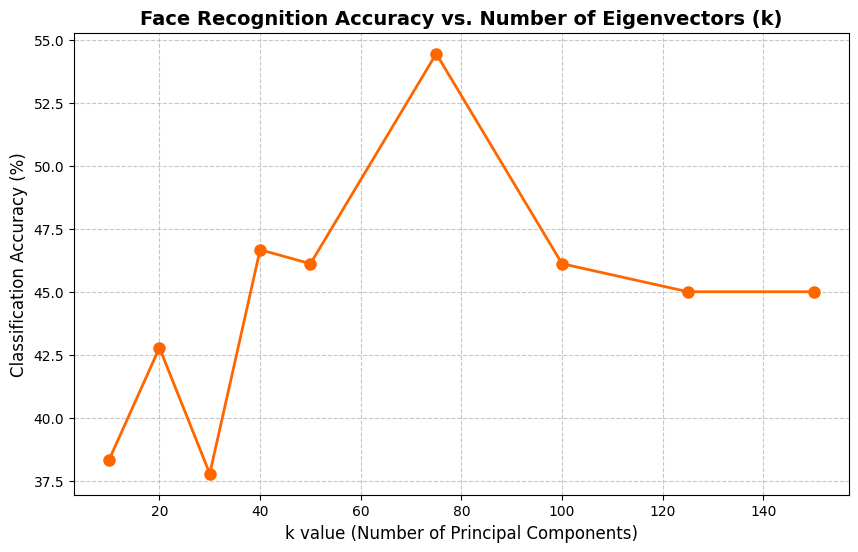

In [ ]:
# ==========================================
# Evaluation Factor A: Accuracy vs. K-Value
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

# The different 'k' values we want to test:
k_values = [10, 20, 30, 40, 50, 75, 100, 125, 150]
accuracies = []

print("Running comparative study... This will take about 30 seconds.")

for k_val in k_values:
    # 1. Recalculate the top 'k' eigenvectors
    evals, psi_k = eigsh(surrogate_cov, k=k_val, which='LM')
    psi_k = psi_k[:, ::-1]

    # 2. Rebuild Eigenfaces and Signatures for this specific 'k':
    phi_k = np.dot(psi_k.T, delta.T)
    omega_k = np.dot(phi_k, delta)

    # 3. Transpose and Split the new data 60/40:
    X_k = omega_k.T
    X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y, test_size=0.40, random_state=42)

    # 4. Train the ANN:
    model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)
    model.fit(X_train_k, y_train_k)

    # 5. Record the accuracy:
    acc = accuracy_score(y_test_k, model.predict(X_test_k))
    accuracies.append(acc * 100)
    print(f"Testing k = {k_val:3d} | Accuracy: {acc * 100:.2f}%")

# 6. Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='#ff6600', linewidth=2, markersize=8)
plt.title('Face Recognition Accuracy vs. Number of Eigenvectors (k)', fontsize=14, fontweight='bold')
plt.xlabel('k value (Number of Principal Components)', fontsize=12)
plt.ylabel('Classification Accuracy (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# ==========================================
# Evaluation Factor B: The Imposter Test
# ==========================================
import urllib.request
import cv2
import numpy as np
from sklearn.neural_network import MLPClassifier
from scipy.spatial.distance import cdist

print("Locking in optimal k=75 and training final ANN...")

# 1. Lock in the best k-value from our graph
optimal_k = 75
evals, psi_opt = eigsh(surrogate_cov, k=optimal_k, which='LM')
psi_opt = psi_opt[:, ::-1]

phi_opt = np.dot(psi_opt.T, delta.T)
omega_opt = np.dot(phi_opt, delta)

# 2. Train the final optimal model
X_final = omega_opt.T
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y, test_size=0.40, random_state=42)
final_model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)
final_model.fit(X_train_f, y_train_f)

print("Downloading Imposter image (A dog)...")

# 3. Download a random "Imposter" image (a dog from Unsplash)
imposter_url = "https://images.unsplash.com/photo-1517849845537-4d257902454a?q=80&w=200&auto=format&fit=crop"
urllib.request.urlretrieve(imposter_url, "imposter.jpg")

# 4. Process the Imposter exactly like our training data
img = cv2.imread("imposter.jpg", cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (100, 100))
imposter_vector = img_resized.flatten().reshape(-1, 1)

# 5. Mean-Zero and Generate Signature for the Imposter
imposter_delta = imposter_vector - mean_face
imposter_signature = np.dot(phi_opt, imposter_delta).T

# 6. Test the Imposter using Distance
# We calculate how far the dog's signature is from the known human signatures
distances = cdist(imposter_signature, X_train_f, 'euclidean')
min_distance = np.min(distances)

print(f"\n--- IMPOSTER TEST RESULTS ---")
print(f"Distance to the closest known human: {min_distance:.2f}")

# Normal faces usually have a distance between 2,000 and 5,000.
# We set a strict threshold.
threshold = 8000

if min_distance > threshold:
    print("SYSTEM ALERT: Signature is too weird. IMPOSTER DETECTED! Access Denied.")
else:
    print("System fooled! The imposter got through.")

Locking in optimal k=75 and training final ANN...

--- IMPOSTER TEST RESULTS ---
Distance to the closest known human: 111145664.73
SYSTEM ALERT: Signature is too weird. IMPOSTER DETECTED! Access Denied.
